# Your First MCMC: Fitting a Planet's Wobble

**Companion lesson:** [`mcmc_exoplanet_lesson.md`](../docs/mcmc_exoplanet_lesson.md) covers the theory: Bayes' theorem, the Boltzmann analogy, and why Metropolis-Hastings samples the right distribution. This notebook is the walk-through of [`mcmc_exoplanet.py`](mcmc_exoplanet.py), with all the code filled in and every step checked.

The story: a star wobbles because of a planet we can't see. We measure the star's radial velocity 50 times with a noisy instrument, and we want to know how big the wobble is. You will:

1. simulate the telescope data,
2. write the **likelihood** of the data for a guessed amplitude $K$,
3. write the **Metropolis-Hastings** loop that samples the posterior $p(K \mid \text{data})$,
4. discard the burn-in and plot the posterior,
5. **check the answer against the exact posterior**. This problem is simple enough to solve on paper, which makes it a good first test for a sampler, and
6. see what goes wrong when the step size is badly chosen.

### How to use this notebook
- Run the cells top to bottom.
- The notebook keeps everything in memory and never writes to `datasets/` or `visualizations/`. (The script saves the data as a CSV file and the posterior plot as an SVG. Here the data are *compared* with the CSV in the repo, and the plot is shown inline.)
- Cells marked **✅ Check** assert something that must be true if the code above them is right.

### A note on names
The script calls the fitted quantity a "mass" (`TRUE_MASS_SINI`, `mass_guess`, `current_mass`), but what it fits is the RV **semi-amplitude** $K$ in m/s, as its own plot labels say. This notebook calls it $K$ everywhere. The formula linking $K$ to the planet's minimum mass $m\sin i$ is derived in the Keplerian lesson.

Three small changes from the script, none of which changes what is computed: a few numbers (period, error bar, ...) are hoisted into named constants, `run_mcmc` takes `start` and `step` arguments whose defaults are the script's values, and `run_mcmc` returns a NumPy array instead of a list.

---
## Part 1: The data

We pretend the planet is on a **circular** orbit with a period of one year, so the star's radial velocity is a sinusoid,

$$V(t) = K \sin\!\left(\frac{2\pi t}{P}\right),$$

and we assume we already know the period $P = 365.25$ days and the phase (the wave is zero at $t = 0$). The only unknown is the amplitude $K$. (The Keplerian notebook drops both assumptions.)

We "observe" the star 50 times at random moments during 3 years. Every measurement has independent Gaussian noise with standard deviation $\sigma = 10$ m/s, and the true amplitude is $K = 50$ m/s. The fixed random seed makes the data, and therefore the whole notebook, reproducible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Plot style shared by all the figures in this notebook (new in this notebook).
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#050b18", "axes.facecolor": "#050b18", "figure.dpi": 110})

PERIOD = 365.25   # orbital period in days (assumed known)
K_TRUE = 50.0     # true semi-amplitude in m/s: the number we hope to recover
N_OBS = 50        # number of observations
BASELINE = 1095   # length of the observing campaign: 3 years, in days
SIGMA = 10.0      # instrument error on every measurement, in m/s


def generate_synthetic_rv_data():
    """Generates synthetic Radial Velocity (RV) data."""
    np.random.seed(42)
    t_observations = np.sort(np.random.uniform(0, BASELINE, N_OBS))
    true_velocities = K_TRUE * np.sin(2 * np.pi * t_observations / PERIOD)
    uncertainties = np.full(N_OBS, SIGMA)
    noisy_velocities = true_velocities + np.random.normal(0, SIGMA, N_OBS)
    return t_observations, noisy_velocities, uncertainties


t, rv_data, rv_err = generate_synthetic_rv_data()

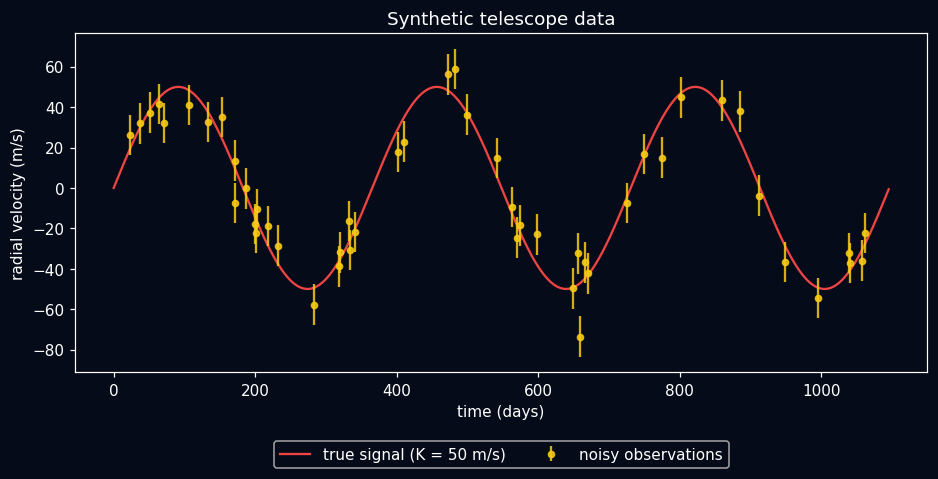

In [2]:
t_grid = np.linspace(0, BASELINE, 1000)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, K_TRUE * np.sin(2 * np.pi * t_grid / PERIOD), color="#ef4444", lw=1.5, label=f"true signal (K = {K_TRUE:.0f} m/s)")
ax.errorbar(t, rv_data, rv_err, fmt="o", ms=4, color="#facc15", alpha=0.85, label="noisy observations")
ax.set(xlabel="time (days)", ylabel="radial velocity (m/s)", title="Synthetic telescope data")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2);

With noise this large (each error bar is 20% of the amplitude) you can see the sine wave, but you could not read $K$ off the plot to better than a few m/s. That is exactly the situation where we want a *distribution* for $K$, not a single number.

### ✅ Check: the same data as the script's

The script also saves the data to `datasets/synthetic_exoplanet_rv.csv` (three columns, rounded to two decimals). If the generator above is faithful to the script's, it must reproduce that file. This cell only *reads* the file.

In [3]:
csv_path = next((f / "datasets" / "synthetic_exoplanet_rv.csv" for f in [Path.cwd(), *Path.cwd().parents]
                 if (f / "datasets" / "synthetic_exoplanet_rv.csv").exists()), None)
if csv_path is None:
    print("datasets/synthetic_exoplanet_rv.csv not found, so this check is skipped")
else:
    saved = np.loadtxt(csv_path, delimiter=",", skiprows=1)  # columns: time, velocity, uncertainty
    assert np.allclose(saved[:, 0], t, atol=0.005) and np.allclose(saved[:, 1], rv_data, atol=0.005), "Different data from the script's"
    assert np.allclose(saved[:, 2], rv_err)
    print(f"✅ Same data as datasets/{csv_path.name} ({len(saved)} rows)")

✅ Same data as datasets/synthetic_exoplanet_rv.csv (50 rows)


---
## Part 2: The likelihood

For a guessed amplitude $K$ the model predicts $K \sin(2\pi t_i/P)$ at every observation time. The **likelihood** $L(K)$ is the probability density of the data we actually saw, if that $K$ were true. With independent Gaussian errors,

$$L(K) \;\propto\; \exp\!\left(-\frac{\chi^2}{2}\right), \qquad \chi^2 = \sum_i \frac{\big(v_i - K\sin(2\pi t_i/P)\big)^2}{\sigma_i^2}.$$

We always work with the logarithm, $\ln L = -\chi^2/2$ (dropping a constant). One reason is practical: a product of many small numbers underflows floating point long before its logarithm gets into trouble.

The other reason is the analogy with statistical mechanics. $L \propto e^{-\chi^2/2}$ has the form of the Boltzmann factor $e^{-E/kT}$, with "energy" $E = \chi^2/2$ (the error-weighted squared misfit) and $kT = 1$. Good fits have low energy and high probability.

In [4]:
def log_likelihood(K_guess, t, rv_data, rv_err):  # rv = radial velocity
    """
    Calculates how well our guessed amplitude fits the data.
    This is mathematically equivalent to the Energy in a Boltzmann distribution.
    """
    # Our model for the radial velocity based on the guessed amplitude
    model_rv = K_guess * np.sin(2 * np.pi * t / PERIOD)

    # Chi-squared represents the sum of the squared errors
    chisq = np.sum(((rv_data - model_rv) / rv_err) ** 2)

    # Our likelihood function is based on the assumption that the errors are Gaussian.
    # So, the log-likelihood is proportional to the negative of 1/2 the chi-squared statistic.
    return -0.5 * chisq

### A problem we can solve exactly

Before sampling anything, notice that this model is **linear** in $K$. Write $s_i = \sin(2\pi t_i / P)$, so that the model is $K s_i$, and expand $\chi^2$:

$$\chi^2(K) = \sum_i \frac{(v_i - K s_i)^2}{\sigma_i^2} = A K^2 - 2BK + C, \qquad A = \sum_i \frac{s_i^2}{\sigma_i^2},\quad B = \sum_i \frac{s_i v_i}{\sigma_i^2},\quad C = \sum_i \frac{v_i^2}{\sigma_i^2}.$$

Completing the square gives $\chi^2(K) = A\,(K - B/A)^2 + \text{const}$, so

$$\ln L(K) = -\frac{A}{2}\left(K - \hat K\right)^2 + \text{const}, \qquad \hat K = \frac{B}{A}.$$

That is the logarithm of a **Gaussian** in $K$. With a flat prior the posterior is proportional to the likelihood, so the posterior is *exactly*

$$p(K \mid \text{data}) = \mathcal{N}\!\left(\hat K,\; \sigma_K^2\right), \qquad \sigma_K = \frac{1}{\sqrt{A}}.$$

$\hat K$ is also the least-squares fit, and $\sigma_K$ is the familiar "error on a fitted amplitude". Real problems, like the seven-parameter Keplerian fit in the next notebook, have no closed form like this, and that is why we need MCMC. But this one does, which means we can **test our sampler against the exact answer**.

In [5]:
s = np.sin(2 * np.pi * t / PERIOD)
A = np.sum(s**2 / rv_err**2)
B = np.sum(s * rv_data / rv_err**2)
K_hat = B / A
sigma_K = 1 / np.sqrt(A)
print(f"Exact posterior: K = {K_hat:.2f} ± {sigma_K:.2f} m/s")

Exact posterior: K = 48.32 ± 2.11 m/s


### ✅ Check: does `log_likelihood` peak where the algebra says?

Scan $\ln L$ over a grid of $K$ values. It should be an exact parabola with its top at $\hat K$, and one $\sigma_K$ away from the top it should have dropped by exactly $\tfrac12$.

✅ log_likelihood is the parabola the algebra predicts


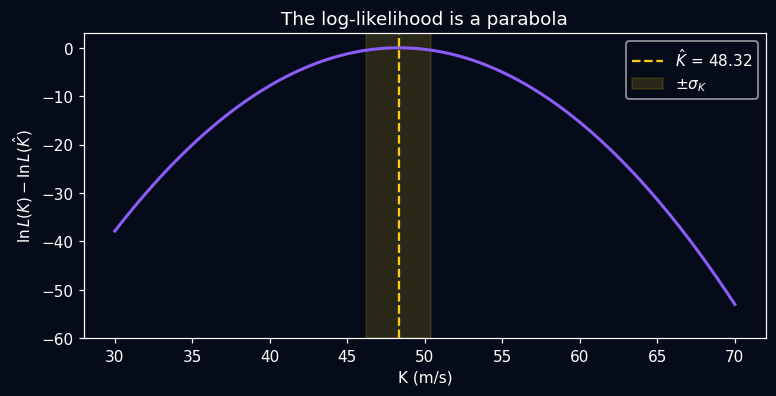

In [6]:
K_grid = np.linspace(30, 70, 401)
ll_grid = np.array([log_likelihood(K, t, rv_data, rv_err) for K in K_grid])
ll_max = log_likelihood(K_hat, t, rv_data, rv_err)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(K_grid, ll_grid - ll_max, color="#8b5cf6", lw=2)
ax.axvline(K_hat, color="#facc15", ls="--", label=rf"$\hat K$ = {K_hat:.2f}")
ax.axvspan(K_hat - sigma_K, K_hat + sigma_K, color="#facc15", alpha=0.15, label=r"$\pm\sigma_K$")
ax.set(xlabel="K (m/s)", ylabel=r"$\ln L(K) - \ln L(\hat K)$", ylim=(-60, 3), title="The log-likelihood is a parabola")
ax.legend()

assert np.isclose(K_grid[np.argmax(ll_grid)], K_hat, atol=0.1), "The likelihood should peak at K_hat"
assert np.isclose(log_likelihood(K_hat + sigma_K, t, rv_data, rv_err) - ll_max, -0.5), "One sigma_K from the peak, ln L should drop by 1/2"
print("✅ log_likelihood is the parabola the algebra predicts")

---
## Part 3: The Metropolis-Hastings loop

The loop below is the algorithm from the lesson, line for line:

1. **Start** somewhere, deliberately far from the truth.
2. **Propose** a new value by adding a Gaussian jump with standard deviation `step`.
3. **Score** the proposal with the likelihood.
4. **Accept** it with probability $\min\!\big(1,\, L_\text{proposed}/L_\text{current}\big)$. In logs that ratio is $e^{\ln L_\text{proposed} - \ln L_\text{current}}$, which is why the code exponentiates a *difference* of log-likelihoods. This is the Metropolis criterion $e^{-\Delta E/kT}$ from statistical mechanics.
5. **Record** the current value, whether or not it just changed. After a rejection the chain repeats itself, and those repeats are what make likely values appear more often in the final histogram.

`start = 10` and `step = 2` are the script's values. A step of 2 m/s is about the width of the posterior, $\sigma_K \approx 2.1$ m/s, which we know from the exact solution above. Part 6 shows what other step sizes do.

In [7]:
def run_mcmc(t, rv_data, rv_err, steps=10000, start=10.0, step=2.0):
    """
    The Metropolis-Hastings Algorithm.
    A random walk through parameter space seeking high probability.
    """
    # 1. Start with a deliberately poor guess (the true value is about 50)
    current_K = start
    current_ll = log_likelihood(current_K, t, rv_data, rv_err)

    samples = []

    for _ in range(steps):
        # 2. Propose a new value (take a random step; the default step size is 2.0 m/s)
        proposed_K = current_K + np.random.normal(0, step)

        # 3. Calculate new likelihood
        proposed_ll = log_likelihood(proposed_K, t, rv_data, rv_err)

        # 4. Calculate Acceptance Probability
        # If proposed_ll > current_ll, the ratio is > 1 (automatically accepted).
        # If it's worse, the ratio is < 1, so we MIGHT accept it.
        # We use np.exp because we are working in Log-Likelihoods.
        if proposed_ll > current_ll:
            acceptance_prob = 1.0
        else:
            # We might still accept a worse guess because MH seeks to generate
            # samples from the posterior distribution, not just the maximum likelihood estimate.
            # As such, we must visit low-density areas LESS OFTEN, but still proportionally
            acceptance_prob = np.exp(proposed_ll - current_ll)

        # 5. Accept or Reject
        if np.random.uniform(0, 1) < acceptance_prob:
            current_K = proposed_K
            current_ll = proposed_ll

        samples.append(current_K)

    return np.array(samples)

In [8]:
# Calling the generator again re-seeds numpy's random number generator (seed 42), so this cell always
# produces the same chain. It mirrors the script's __main__ block: generate the data, then run the sampler.
t, rv_data, rv_err = generate_synthetic_rv_data()
samples = run_mcmc(t, rv_data, rv_err, steps=10_000)

print(f"{len(samples):,} samples. The first 15:")
print(np.round(samples[:15], 2))

10,000 samples. The first 15:
[10.19 12.13 12.13 12.13 12.72 13.25 13.25 13.25 13.25 14.05 14.57 14.42
 14.42 14.37 14.49]


Look at the first few numbers. The chain climbs from the starting point of 10 towards the answer, and some values **repeat**: those are rejected proposals, where the chain stayed put and recorded its current value again.

---
## Part 4: Reading the chain

### The trace plot and burn-in

A **trace plot** shows the chain's value against the step number. Ours starts at 10 m/s, far below the answer, and climbs. The early steps are not draws from the posterior, because they remember the arbitrary starting point, so we throw them away as **burn-in**. How many steps? The script discards the first 1,000. The left panel zooms in on the climb to show how generous that is.

The chain first enters the exact posterior's ±2σ band at step 46, so 1,000 steps of burn-in is generous (and cheap).
Acceptance fraction after burn-in: 0.73


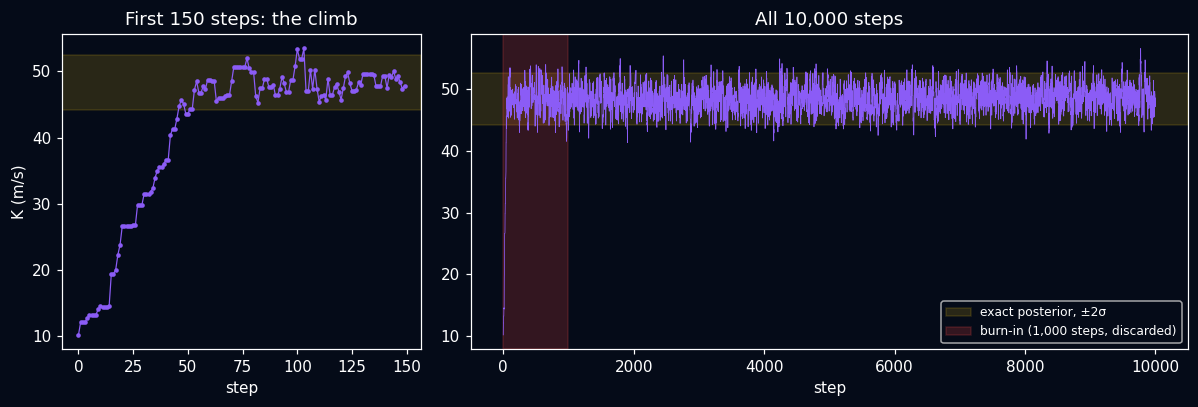

In [9]:
BURN_IN = 1000  # steps discarded before summarizing, as in the script
band = (K_hat - 2 * sigma_K, K_hat + 2 * sigma_K)  # the exact posterior, plus and minus 2 sigma

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 2]})
ax1.plot(np.arange(150), samples[:150], ".-", color="#8b5cf6", ms=4, lw=0.8)
ax1.axhspan(*band, color="#facc15", alpha=0.15)
ax1.set(xlabel="step", ylabel="K (m/s)", title="First 150 steps: the climb")

ax2.plot(samples, color="#8b5cf6", lw=0.5)
ax2.axhspan(*band, color="#facc15", alpha=0.15, label="exact posterior, ±2σ")
ax2.axvspan(0, BURN_IN, color="#ef4444", alpha=0.2, label=f"burn-in ({BURN_IN:,} steps, discarded)")
ax2.set(xlabel="step", title="All 10,000 steps")
ax2.legend(loc="lower right", fontsize=8)
fig.tight_layout()

first_in_band = int(np.argmax(np.abs(samples - K_hat) < 2 * sigma_K))
print(f"The chain first enters the exact posterior's ±2σ band at step {first_in_band}, so {BURN_IN:,} steps of burn-in is generous (and cheap).")

post = samples[BURN_IN:]
acceptance = np.mean(post[1:] != post[:-1])  # the fraction of steps on which the chain moved
print(f"Acceptance fraction after burn-in: {acceptance:.2f}")

### The acceptance fraction

The **acceptance fraction** is the share of proposals that were accepted, which we can read off the chain as the share of steps on which the value changed. It is the quickest health check for a sampler, and it depends on the step size: a tiny step is almost always accepted, and a huge step almost never. Part 6 works out what to expect.

---
## Part 5: The posterior

After the burn-in, a histogram of the visited values approximates the posterior. `plot_posterior` is the script's plot: a histogram, the chain's mean, and the true value. This version returns the figure instead of saving an SVG, and it can also draw the **exact posterior** from Part 2 in white.

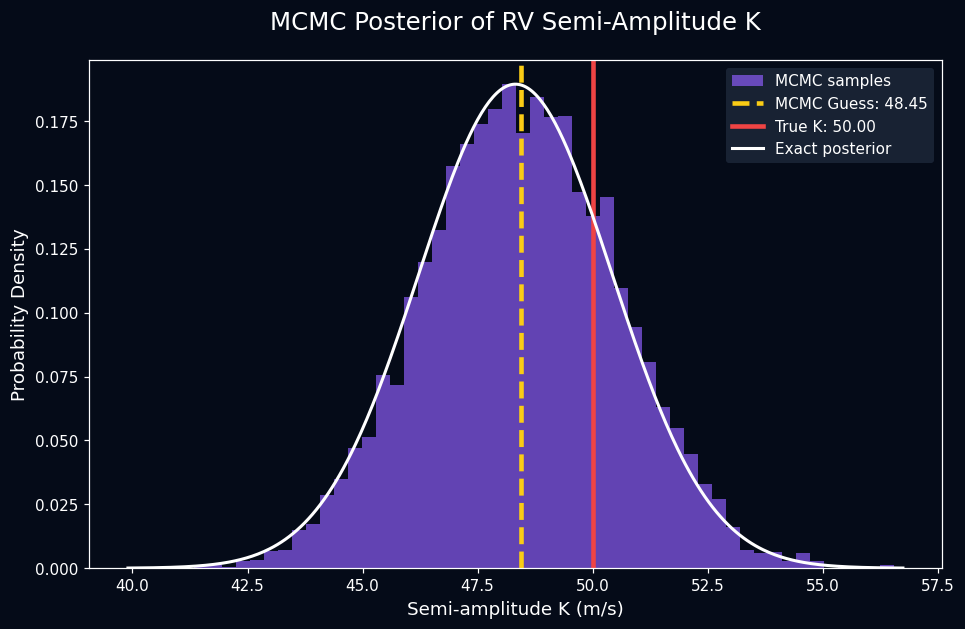

In [10]:
def plot_posterior(samples, burn_in=1000, exact=None):
    """Plots a histogram of all the values of K the MCMC walker visited."""
    # Burn-in: We discard the first 1000 steps where the walker was still walking
    # towards the "high probability" valley from its starting point.
    valid_samples = samples[burn_in:]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(valid_samples, bins=50, color="#8b5cf6", alpha=0.7, density=True, label="MCMC samples")
    ax.axvline(np.mean(valid_samples), color="#facc15", linestyle="dashed", linewidth=3, label=f"MCMC Guess: {np.mean(valid_samples):.2f}")
    ax.axvline(K_TRUE, color="#ef4444", linestyle="solid", linewidth=3, label=f"True K: {K_TRUE:.2f}")

    if exact is not None:  # optional: overlay the exact Gaussian posterior (new in this notebook)
        mean, sd = exact
        x = np.linspace(mean - 4 * sd, mean + 4 * sd, 400)
        ax.plot(x, np.exp(-0.5 * ((x - mean) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)), color="white", linewidth=2, label="Exact posterior")

    ax.set_title("MCMC Posterior of RV Semi-Amplitude K", pad=20, fontsize=16)
    ax.set_xlabel("Semi-amplitude K (m/s)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(facecolor="#1e293b", edgecolor="none")
    return fig


plot_posterior(samples, burn_in=BURN_IN, exact=(K_hat, sigma_K));

In [11]:
post = samples[BURN_IN:]
lo, med, hi = np.percentile(post, [16, 50, 84])
print(f"{'':>24} {'mean':>7} {'std':>6}")
print(f"{'exact posterior':>24} {K_hat:7.2f} {sigma_K:6.2f}")
print(f"{'MCMC, after burn-in':>24} {post.mean():7.2f} {post.std():6.2f}")
print(f"{'MCMC, burn-in kept':>24} {samples.mean():7.2f} {samples.std():6.2f}")
print(f"{'truth':>24} {K_TRUE:7.2f}")
print(f"\nMCMC median and 68% interval: {med:.2f} +{hi - med:.2f} -{med - lo:.2f} m/s")
print(f"The truth is {abs(K_TRUE - K_hat) / sigma_K:.1f} sigma from the exact posterior mean")

                            mean    std
         exact posterior   48.32   2.11
     MCMC, after burn-in   48.45   2.10
      MCMC, burn-in kept   48.33   2.72
                   truth   50.00

MCMC median and 68% interval: 48.42 +2.12 -2.06 m/s
The truth is 0.8 sigma from the exact posterior mean


### ✅ Check: does the sampler reproduce the exact posterior?

If Metropolis-Hastings is working, the chain's mean and standard deviation, after the burn-in, should match the exact $\hat K$ and $\sigma_K$. They won't agree to the last digit, because a finite, correlated chain has its own small Monte Carlo error, but they should agree to a small fraction of $\sigma_K$.

In [12]:
assert abs(post.mean() - K_hat) < 0.25, "The chain's mean should match the exact posterior mean"
assert abs(post.std() / sigma_K - 1) < 0.10, "The chain's spread should match the exact posterior width"
print(f"✅ Mean off by {abs(post.mean() - K_hat):.2f} m/s and spread off by {abs(post.std() / sigma_K - 1):.1%}: the sampler reproduces the exact posterior")

✅ Mean off by 0.12 m/s and spread off by 0.3%: the sampler reproduces the exact posterior


### Reading the results

1. **The sampler is right.** Its mean and width agree with the exact posterior to within about a tenth of $\sigma_K$. The small remaining difference is Monte Carlo noise.
2. **Burn-in matters.** Keeping the first steps makes the spread noticeably too wide, because the climb from 10 m/s adds a long tail to the histogram.
3. **The truth is not the posterior mean, and that is fine.** The posterior is centred on the value this *particular* noisy data set favours, not on the true $K$. The truth lies within about one $\sigma_K$ of it, which is what the posterior width says to expect. MCMC does not remove the statistical uncertainty in the data. It represents it faithfully.

---
## Part 6: Choosing the step size

`run_mcmc` has one tuning knob, `step`, and the sampler is only as good as that setting. Here are three runs from the same start, with the same random numbers, at very different step sizes:

- **Too small (0.2 m/s).** Nearly every proposal is accepted, but each one barely moves the chain. It creeps along like a slow random walk, takes most of a thousand steps to reach the posterior (so the 1,000-step burn-in only just covers it), and consecutive samples are almost identical. So 10,000 samples contain far fewer than 10,000 independent draws.
- **The script's choice (2 m/s).** About the width of the posterior. The chain arrives within a few dozen steps and explores the posterior briskly.
- **Too large (50 m/s).** Almost every proposal lands far out in the tails and is rejected, so the chain sits still for long stretches, repeating the same value.

The acceptance fraction diagnoses all of this. For a Gaussian posterior of width $\sigma_K$ and a Gaussian proposal of width `step`, it has an exact closed form,

$$\text{acceptance} = \frac{2}{\pi}\arctan\!\left(\frac{2\sigma_K}{\text{step}}\right).$$

(It equals twice the probability that a proposal lands *closer* to the peak than the current point, which for Gaussians works out to an angle.) The measured values in the table below should match it. A separate result (Roberts, Gelman & Gilks, 1997) says the most *efficient* step for a Gaussian target is about $2.4\,\sigma_K$, and the formula tells us the acceptance there: 44%. The penalty for missing that optimum is mild within a factor of two or so, and severe far outside that range.

step (m/s)  acceptance  theory  steps to reach ±2σ    mean    std
       0.2        0.97    0.97                 830   48.04   2.14


         2        0.73    0.72                  39   48.34   2.06


        50        0.06    0.05                   5   48.19   2.14


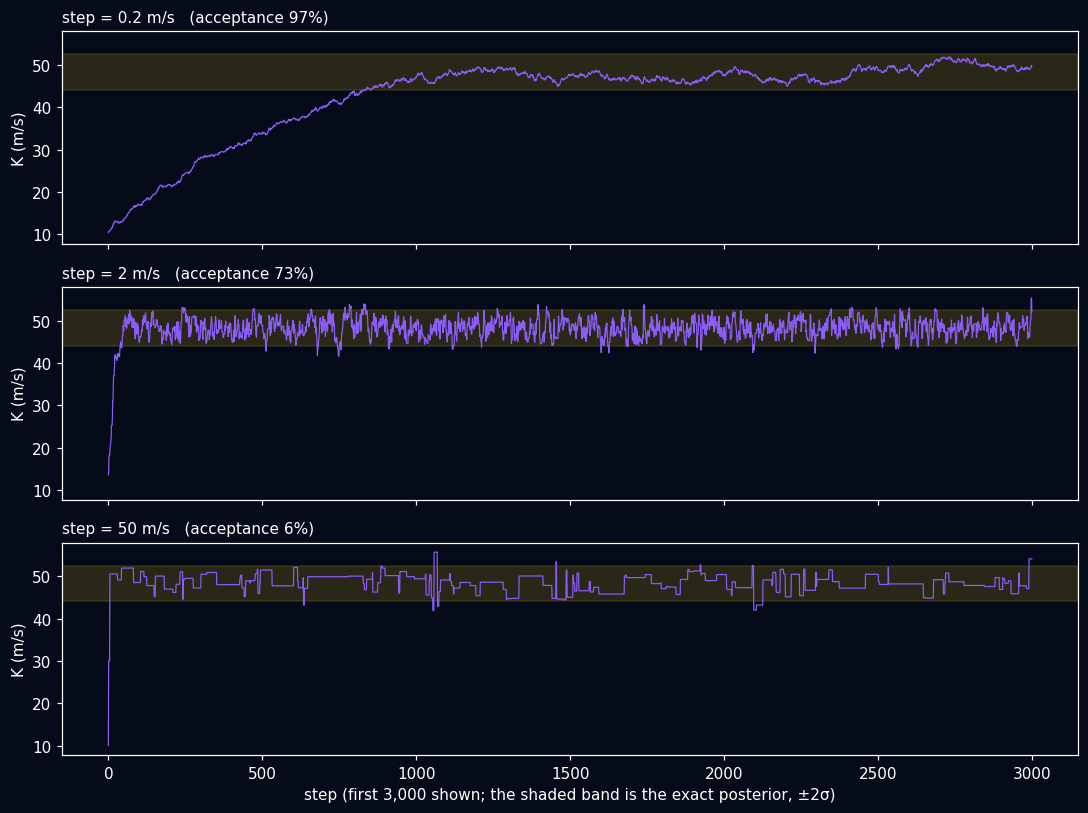

In [13]:
STEP_SIZES = [0.2, 2.0, 50.0]  # m/s: too small, the script's choice, too large

fig, axes = plt.subplots(len(STEP_SIZES), 1, figsize=(10, 7.5), sharex=True, sharey=True)
print(f"{'step (m/s)':>10}  {'acceptance':>10}  {'theory':>6}  {'steps to reach ±2σ':>18}  {'mean':>6}  {'std':>5}")
for ax, step_size in zip(axes, STEP_SIZES):
    np.random.seed(0)  # the same random numbers for every step size, and reproducible
    chain = run_mcmc(t, rv_data, rv_err, steps=10_000, step=step_size)
    chain_post = chain[BURN_IN:]
    chain_acceptance = np.mean(chain_post[1:] != chain_post[:-1])
    theory = 2 / np.pi * np.arctan(2 * sigma_K / step_size)
    arrival = int(np.argmax(np.abs(chain - K_hat) < 2 * sigma_K))  # the first step inside the exact ±2σ band
    print(f"{step_size:10g}  {chain_acceptance:10.2f}  {theory:6.2f}  {arrival:18d}  {chain_post.mean():6.2f}  {chain_post.std():5.2f}")
    assert abs(chain_acceptance - theory) < 0.05, "The acceptance fraction should match the closed-form value"

    ax.plot(chain[:3000], color="#8b5cf6", lw=0.8)
    ax.axhspan(*band, color="#facc15", alpha=0.15)
    ax.set_title(f"step = {step_size:g} m/s   (acceptance {chain_acceptance:.0%})", loc="left", fontsize=10)
    ax.set_ylabel("K (m/s)")
axes[-1].set_xlabel("step (first 3,000 shown; the shaded band is the exact posterior, ±2σ)")
fig.tight_layout()

Read the three traces top to bottom. The small step gives a smooth, slowly wandering curve that only reaches the band after roughly 800 steps (see the "steps to reach" column), and even then it drifts slowly rather than jumping around. The script's step reaches the band within a few dozen steps and then fuzzes around inside it. The huge step reaches it almost at once, because a big jump can land there directly, but afterwards it is flat for long stretches (rejections) and then jumps. All three end up sampling the same posterior, and the table shows their means and widths are all close to the exact values. They do it at very different cost.

Turning "this trace looks sticky" into a number is the job of the **autocorrelation time**, which the Keplerian notebook introduces.

---
## What this sampler can't do (yet)

This notebook worked because the problem was gentle: one parameter, a Gaussian posterior, and a step size we could tune by looking at the answer. Real fits are not like that. Each shortcut we took is removed in [`keplerian_rv_fit.ipynb`](keplerian_rv_fit.ipynb):

| Here | Next |
|---|---|
| Period and phase known | Full Keplerian orbit, with the period *found* by a periodogram |
| One parameter | Seven parameters, with wildly different scales and correlations |
| One hand-tuned step size | An ensemble sampler (Goodman & Weare) that adapts to the posterior's shape |
| Known noise level | An extra "jitter" parameter for stellar noise |
| Burn-in judged by eye | Convergence measured with the autocorrelation time |
| Checked against an exact answer | No exact answer exists, so the sampler is tested on problems whose answers are known |

**Things to try**
1. Pass `start=200` to `run_mcmc` in Part 3 and watch the burn-in in Part 4. Is 1,000 steps still enough?
2. Make the data noisier (`SIGMA = 30`) and re-run everything. How does the posterior change? The exact formula says $\sigma_K \propto \sigma$.
3. Try a proposal that is *not* symmetric, for example a jump drawn from an exponential distribution. What has to change in the acceptance rule? (Hint: the Hastings correction in the lesson.)